In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

In [3]:
df = pd.read_csv(".\X_train\clinical_train.csv")
gene_df = pd.read_csv('.\X_train\molecular_train.csv')
target_df = pd.read_csv('target_train.csv')

In [4]:
def howManyNa(df):
    for c in df.columns.tolist():
        naCols = df[df[c].isna()].shape[0]
        print(f' {c} has {naCols} empty rows')

howManyNa(gene_df)

 ID has 0 empty rows
 CHR has 114 empty rows
 START has 114 empty rows
 END has 114 empty rows
 REF has 114 empty rows
 ALT has 114 empty rows
 GENE has 0 empty rows
 PROTEIN_CHANGE has 12 empty rows
 EFFECT has 0 empty rows
 VAF has 89 empty rows
 DEPTH has 114 empty rows


In [7]:
gene_df['EFFECT'].unique()

array(['non_synonymous_codon', 'stop_gained', 'splice_site_variant',
       'frameshift_variant', 'inframe_codon_loss', 'inframe_codon_gain',
       'initiator_codon_change', '2KB_upstream_variant',
       'complex_change_in_transcript', '3_prime_UTR_variant', 'stop_lost',
       'inframe_variant', 'synonymous_codon', 'stop_retained_variant',
       'ITD', 'PTD'], dtype=object)

In [113]:
df['CYTOGENETICS'].head()

0        46,xy,del(20)(q12)[2]/46,xy[18]
1                                  46,xx
2     46,xy,t(3;3)(q25;q27)[8]/46,xy[12]
3      46,xy,del(3)(q26q27)[15]/46,xy[5]
4    46,xx,t(3;9)(p13;q22)[10]/46,xx[10]
Name: CYTOGENETICS, dtype: object

In [114]:
def isNormal(karotype):
    reg = r'^(46,x[xy]\[\d{1,2}\]|46,x[xy])$'
    match = re.match(reg,karotype)
    if match:
        return True
    else:
        return False

def extractNormalCells(karotype):
    reg = r'^46,x[xy]\[(\d{1,2})\]$'
    m1 = re.match(r'^46,x[xy]$',karotype)
    if m1:
        return 20
    match = re.match(reg,karotype)
    if match:
        return int(match.group(1))
    else:
        return 0

def extractAbnormalCells(karotype):
    reg = r'\[(\d{1,2})\]$'
    m1 = re.search(r'complex',karotype)
    if m1:
        return 20
    match = re.search(reg,karotype)
    if not isNormal(karotype):
        if match:
            return int(match.group(1))
        else:
            return 0

def extractAbnormalityTypes(karotype,abnormality):
    c = karotype.count(abnormality)
    return c

def countMonosomy(karotype):
    reg = r'-\d{1,2}'
    match = re.findall(reg,karotype)
    return len(match)

def addColumns(row):
    abnormal = 0
    normal = 0
    deletions = 0
    additions = 0
    inversions = 0
    translocations = 0
    monosomy = 0
    isComplex = 0
    karotype = row['CYTOGENETICS']
    if not isinstance(karotype,str):
        row['ABNORMAL_CELL_COUNT'] = None
        row['NORMAL_CELL_COUNT'] = None
        row['IS_COMPLEX'] = isComplex
        row['DELETIONS'] = None
        row['ADDITIONS'] = None
        row['INVERSIONS'] = None
        row['TRANSLOCATIONS'] = None 
        row['MONOSOMY'] = None
        return row
        
    if karotype == 'complex':
        isComplex = 1

    karotypes = karotype.split('/')
    for k in karotypes:
        if isNormal(k):
            normal += extractNormalCells(k)
        else:
            abnormal += extractAbnormalCells(k)
            deletions += extractAbnormalityTypes(k,'del')
            additions += extractAbnormalityTypes(k,'add')
            inversions += extractAbnormalityTypes(k,'inv')
            translocations += extractAbnormalityTypes(k,'t')
            monosomy += countMonosomy(k)
    
    row['ABNORMAL_CELL_COUNT'] = abnormal
    row['NORMAL_CELL_COUNT'] = normal
    row['IS_COMPLEX'] = isComplex
    row['DELETIONS'] = deletions
    row['ADDITIONS'] = additions
    row['INVERSIONS'] = inversions
    row['TRANSLOCATIONS'] = translocations 
    row['MONOSOMY'] = monosomy
    return row
        
#t = extractNormalCells('46,xy')
#print(t)


In [115]:
df = df.apply(addColumns,axis=1)

In [116]:
df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,ABNORMAL_CELL_COUNT,NORMAL_CELL_COUNT,IS_COMPLEX,DELETIONS,ADDITIONS,INVERSIONS,TRANSLOCATIONS,MONOSOMY
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",2.0,18.0,0,1.0,0.0,0.0,0.0,0.0
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx",0.0,20.0,0,0.0,0.0,0.0,0.0,0.0
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",8.0,12.0,0,0.0,0.0,0.0,1.0,0.0
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",15.0,5.0,0,1.0,0.0,0.0,0.0,0.0
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",10.0,10.0,0,0.0,0.0,0.0,1.0,0.0


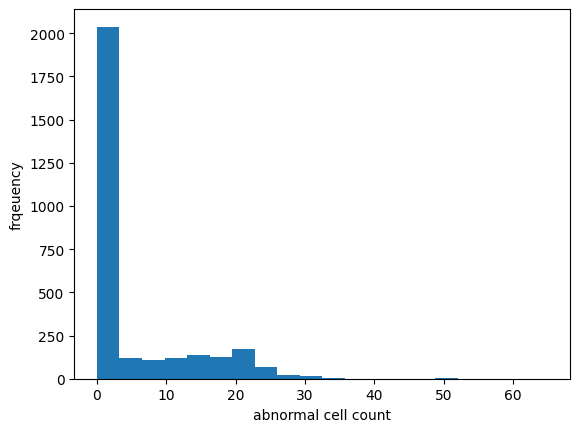

4.741144414168938 0.0


In [60]:
temp = df[df['ABNORMAL_CELL_COUNT'].notna()]
X = temp['ABNORMAL_CELL_COUNT']
plt.hist(X,bins=20)
plt.xlabel('abnormal cell count')
plt.ylabel('frqeuency')
plt.show()
print(np.mean(X),np.median(X))

In [105]:
c =  ["BM_BLAST","WBC","ANC","MONOCYTES","HB","PLT","PERCENT_ABNORMAL",'DELETIONS','ADDITIONS','INVERSIONS','TRANSLOCATIONS','MONOSOMY','IS_COMPLEX']
matrix = df[c].corr()
#print(matrix)

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

columns = ['BM_BLAST', 'WBC','HB', 'PLT','ANC','MONOCYTES','ABNORMAL_CELL_COUNT','NORMAL_CELL_COUNT','DELETIONS','ADDITIONS','INVERSIONS','TRANSLOCATIONS','MONOSOMY']
df[columns] = imputer.fit_transform(df[columns])
df['PERCENT_ABNORMAL'] = df['ABNORMAL_CELL_COUNT']/(df['ABNORMAL_CELL_COUNT']+df['NORMAL_CELL_COUNT'])
df['PERCENT_ABNORMAL'] = df['PERCENT_ABNORMAL'].fillna(0)

In [ ]:
#features = ["BM_BLAST","WBC","ANC","MONOCYTES","HB","PLT","PERCENT_ABNORMAL",'DELETIONS','ADDITIONS','INVERSIONS','TRANSLOCATIONS','MONOSOMY','IS_COMPLEX']
#features = ["BM_BLAST","WBC","ANC","HB","PERCENT_ABNORMAL","IS_COMPLEX"]

#no monocytes, anc, additions, trans
features = ["BM_BLAST","WBC","HB","PLT","PERCENT_ABNORMAL",'DELETIONS','INVERSIONS','MONOSOMY','IS_COMPLEX'] #- 0.68 on train

target = ['OS_YEARS', 'OS_STATUS']

target_df.dropna(subset=['OS_YEARS', 'OS_STATUS'], inplace=True)

# Check the data types to ensure 'OS_STATUS' is boolean and 'OS_YEARS' is numeric
print(target_df[['OS_STATUS', 'OS_YEARS']].dtypes)

# Contarget_dfvert 'OS_YEARS' to numeric if it isn’t already
target_df['OS_YEARS'] = pd.to_numeric(target_df['OS_YEARS'], errors='coerce')

# Ensure 'OS_STATUS' is boolean
target_df['OS_STATUS'] = target_df['OS_STATUS'].astype(bool)

# Create the survival data format
X = df.loc[df['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

OS_STATUS       bool
OS_YEARS     float64
dtype: object


In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [125]:

#X_train[['BM_BLAST', 'WBC','HB', 'PLT','ANC','MONOCYTES','ABNORMAL_CELL_COUNT','NORMAL_CELL_COUNT']] = imputer.fit_transform(X_train[['BM_BLAST', 'WBC','HB', 'PLT','ANC','MONOCYTES','ABNORMAL_CELL_COUNT','NORMAL_CELL_COUNT']])
#X_test[['BM_BLAST', 'WBC','HB', 'PLT','ANC','MONOCYTES','ABNORMAL_CELL_COUNT','NORMAL_CELL_COUNT']] = imputer.transform(X_test[['BM_BLAST', 'WBC','HB', 'PLT','ANC','MONOCYTES','ABNORMAL_CELL_COUNT','NORMAL_CELL_COUNT']])

In [126]:

cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
#cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.2f}")
#print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.2f}")

C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The CoxPHSurvivalAnalysis or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Cox Proportional Hazard Model Concordance Index IPCW on train: 0.65


C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The CoxPHSurvivalAnalysis or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
C:\Users\sheno\Downloads\soton_y3\challenge\VENV\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


             feature      beta
0           BM_BLAST  0.028546
1                WBC  0.009692
2                ANC  0.005138
3                 HB -0.157666
4                PLT -0.001927
5   PERCENT_ABNORMAL  0.385938
6          DELETIONS  0.088591
7          ADDITIONS  0.058988
8         INVERSIONS  0.251483
9     TRANSLOCATIONS -0.006572
10          MONOSOMY  0.136804
11        IS_COMPLEX  0.979755


In [ ]:
import lightgbm as lgb
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Define LightGBM parameters
lgbm_params = {
    'max_depth': 3,
    'learning_rate': 0.05,
    'verbose': -1
}

# Prepare the data for LightGBM
# Scale the target (OS_YEARS) to reduce skew, apply weights based on event status
X_train_lgb = X_train  # Features for training
y_train_transformed = y_train['OS_YEARS']

# Create LightGBM dataset
train_dataset = lgb.Dataset(X_train_lgb, label=y_train_transformed)

# Train the LightGBM modelmodel = lgb.train(params=lgbm_params, train_set=train_dataset)

# Make predictions on the training and testing sets
pred_train = -model.predict(X_train)
#pred_test = -model.predict(X_test)

# Evaluate the model using Concordance Index IPCW
train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
#test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
print(f"LightGBM Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
#print(f"LightGBM Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")


LightGBM Survival Model Concordance Index IPCW on train: 0.70
LightGBM Survival Model Concordance Index IPCW on test: 0.66
